#  Skincare Product Recommendation — Machine Learning Project

**Dataset:** AI Skincare Personalization (Kaggle)  


##  Struktura e Projektit

| # | Seksioni |
|---|----------|
| 1 | Ngarkimi i bibliotekave dhe të dhënave |
| 2 | Parapërpunimi (Preprocessing) |
| 3 | Analiza Eksploratore (EDA) |
| 4 | Inxhinieria e Veçorive (Feature Engineering) |
| 5 | Klasifikimi — 5 modele + Hyperparameter Tuning |
| 6 | Rrjeta Neurale (MLP) — 2 arkitektura |
| 7 | Krahasimi i Modeleve |
| 8 | Grupimi (K-Means Clustering) |
| 9 | Konkluzionet Finale |

## 1. Ngarkimi i Bibliotekave dhe Të Dhënave

In [88]:
# Importojmë të gjitha bibliotekat e nevojshme
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & splitting
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.feature_selection import SelectKBest, f_classif

# Klasifikuesit
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrikat e vlerësimit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Clustering dhe reduktimi i dimensioneve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Stilizimi i grafikave
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(" Bibliotekat u ngarkuan me sukses")

 Bibliotekat u ngarkuan me sukses


In [89]:
# Ngarkojmë të tre datasetet
users        = pd.read_csv('users.csv')
products     = pd.read_csv('skincare_100.csv')
interactions = pd.read_csv('interactions.csv')


if 'category' in products.columns and 'Category' not in products.columns:
    products = products.rename(columns={'category': 'Category'})


print(f"users.csv          → {users.shape[0]:>6,} rreshta  ×  {users.shape[1]} kolona")
print(f"skincare_100.csv   → {products.shape[0]:>6,} rreshta  ×  {products.shape[1]} kolona")
print(f"interactions.csv   → {interactions.shape[0]:>6,} rreshta  ×  {interactions.shape[1]} kolona")

users.csv          → 15,000 rreshta  ×  13 kolona
skincare_100.csv   →    100 rreshta  ×  7 kolona
interactions.csv   → 75,000 rreshta  ×  3 kolona


In [90]:
# Shikojmë disa shembuj nga secili dataset
print("── Shembuj nga Users ──")
display(users.head(3))

print("── Shembuj nga Products ──")
display(products.head(3))

print("── Shembuj nga Interactions ──")
display(interactions.head(3))

── Shembuj nga Users ──


,User_ID,Age,Skin_Type,Skin_Tone,Climate,Diet,Hormonal_Status,Budget_Level,Acne_Severity,Dryness_Severity,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity
0,0,43,Sensitive,Medium,Humid,Vegan,Pregnant,High,0.000000,0.000000,0.000000,2.4,6.336962
1,1,29,Sensitive,Deep,Cold,Vegan,Teen,High,4.545657,3.589760,4.333578,0.0,7.976537
2,2,22,Dry,Medium,Humid,High_Dairy,Pregnant,High,0.000000,8.522342,0.000000,0.0,0.000000


── Shembuj nga Products ──


,id,Product_ID,name,Brand,Category,Price,Ingredients
0,0,453,BudgetBeauty Moisturizer,BudgetBeauty,Moisturizer,96,Retinol|Hyaluronic Acid|Ceramides
1,1,30,LuxuryGlow Moisturizer,LuxuryGlow,Moisturizer,140,Hyaluronic Acid
2,2,240,LuxuryGlow Moisturizer,LuxuryGlow,Moisturizer,125,Ceramides


── Shembuj nga Interactions ──


,User_ID,Product_ID,User_Rating
0,0,114,2.38
1,0,63,3.97
2,0,560,3.10


## 2. Parapërpunimi (Preprocessing)

Para çdo modelimi duhet të kuptojmë cilësinë e të dhënave:
- A ka vlera të munguara?
- Si duket shpërndarja e veçorive numerike?
- Si i trajtojmë kolonat speciale si `Ingredients`?

In [91]:
# Kontrollojmë vlerat e munguara në të tre datasetet
print("=== Vlerat e Munguara ===")
for name, df_ in [("users", users), ("products", products), ("interactions", interactions)]:
    missing = df_.isnull().sum().sum()
    print(f"  {name:>12}: {missing} vlerë të munguara")

=== Vlerat e Munguara ===
         users: 0 vlerë të munguara
      products: 0 vlerë të munguara
  interactions: 0 vlerë të munguara


In [92]:
# Statistika bazë për kolonat numerike
print("── Statistikat e Users (kolonat numerike) ──")
display(users.describe().round(2))

print("\n── Statistikat e Çmimeve të Produkteve ──")
display(products[['Price']].describe().round(2))

print("\n── Statistikat e Vlerësimeve ──")
display(interactions['User_Rating'].describe().round(2))

── Statistikat e Users (kolonat numerike) ──


,User_ID,Age,Acne_Severity,Dryness_Severity,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7499.50,31.99,3.32,2.19,1.81,0.88,1.34
std,4330.27,10.00,3.27,3.19,2.27,1.32,2.66
min,0.00,15.00,0.00,0.00,0.00,0.00,0.00
25%,3749.75,23.00,0.00,0.00,0.00,0.00,0.00
50%,7499.50,32.00,2.86,0.00,0.00,0.00,0.00
75%,11249.25,40.00,5.53,3.47,4.13,1.50,0.00
max,14999.00,49.00,10.00,10.00,6.00,4.20,8.00



── Statistikat e Çmimeve të Produkteve ──


,Price
count,100.00
mean,75.27
std,41.30
min,11.00
25%,39.75
50%,70.50
75%,113.25
max,149.00



── Statistikat e Vlerësimeve ──


count    75000.00
mean         3.51
std          0.71
min          1.00
25%          3.03
50%          3.51
75%          4.00
max          5.00
Name: User_Rating, dtype: float64

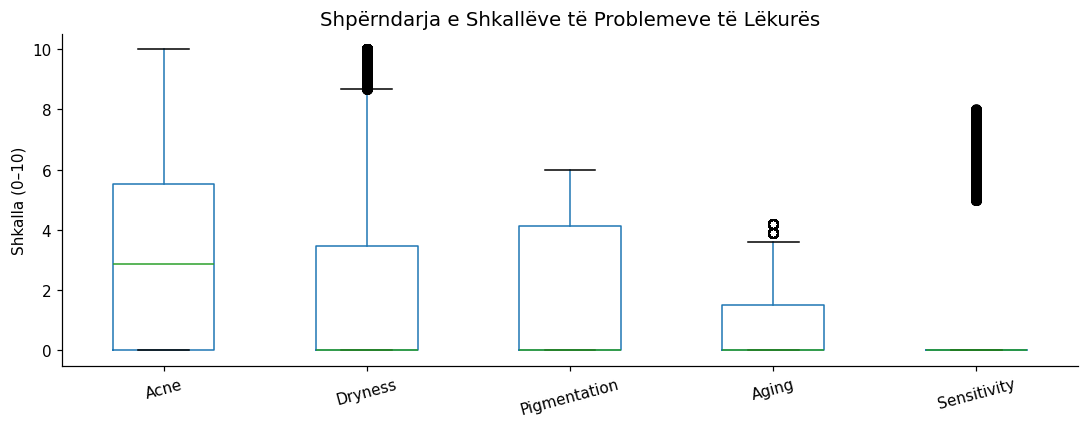

In [93]:
# Vizualizojmë shpërndarjen e problemeve të lëkurës me boxplot
# Boxplot tregon: mesataren, kuartilet dhe vlerat ekstreme (outliers)
severity_cols = ['Acne_Severity', 'Dryness_Severity',
                 'Pigmentation_Severity', 'Aging_Severity', 'Sensitivity_Severity']

fig, ax = plt.subplots(figsize=(10, 4))
users[severity_cols].boxplot(ax=ax, grid=False)
ax.set_title("Shpërndarja e Shkallëve të Problemeve të Lëkurës", fontsize=13)
ax.set_ylabel("Shkalla (0–10)")
ax.set_xticklabels([c.replace('_Severity', '') for c in severity_cols], rotation=15)
plt.tight_layout()
plt.show()


In [94]:
# Ndajmë kolonën Ingredients (e ndarë me '|') në listë ingredientësh
products['Ingredients'] = products['Ingredients'].str.split('|')

print("Shembull — kolona Ingredients pas ndarjes:")
display(products[['Product_ID', 'Brand', 'Price', 'Ingredients']].head(4))

Shembull — kolona Ingredients pas ndarjes:


,Product_ID,Brand,Price,Ingredients
0,453,BudgetBeauty,96,"[Retinol, Hyaluronic Acid, Ceramides]"
1,30,LuxuryGlow,140,[Hyaluronic Acid]
2,240,LuxuryGlow,125,[Ceramides]
3,366,ClinicalSkin,84,"[Ceramides, Retinol]"


In [95]:
# One-Hot Encoding i ingredientëve me MultiLabelBinarizer
# Çdo ingredient bëhet kolona e veçantë (0 ose 1)
mlb = MultiLabelBinarizer()
ing_matrix = mlb.fit_transform(products['Ingredients'])
ing_df = pd.DataFrame(ing_matrix, columns=[f"Ing_{c}" for c in mlb.classes_])
ing_df.insert(0, 'Product_ID', products['Product_ID'].values)

print("Ingredientët e gjetur:", list(mlb.classes_))
print(f"Dimensionet e matricës: {ing_df.shape}")
display(ing_df.head(3))

Ingredientët e gjetur: ['Ceramides', 'Hyaluronic Acid', 'Retinol', 'Salicylic Acid', 'Vitamin C']
Dimensionet e matricës: (100, 6)


,Product_ID,Ing_Ceramides,Ing_Hyaluronic Acid,Ing_Retinol,Ing_Salicylic Acid,Ing_Vitamin C
0,453,1,1,1,0,0
1,30,0,1,0,0,0
2,240,1,0,0,0,0


## 3. Analiza Eksploratore (EDA)

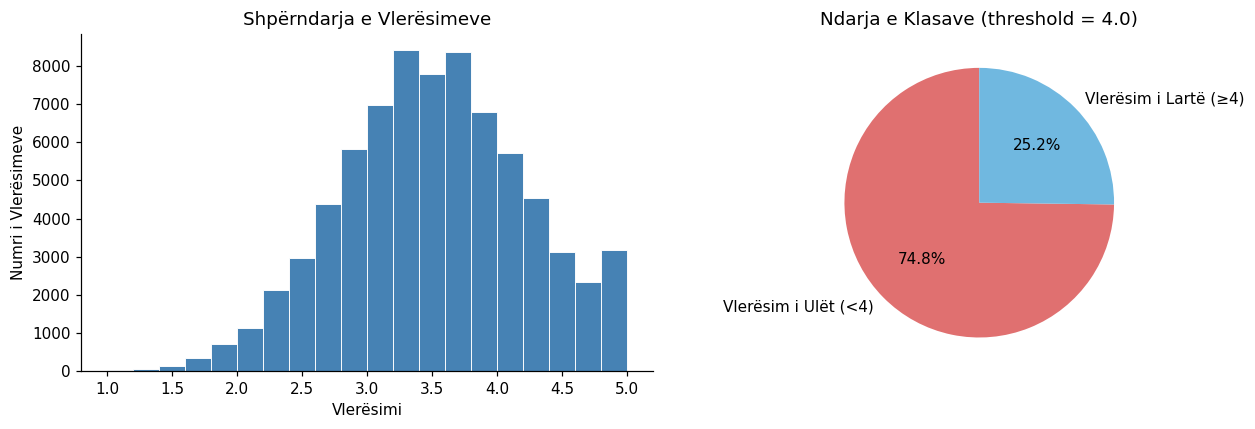

In [96]:
# Shpërndarja e vlerësimeve dhe ndarja e klasave binare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram i vlerësimeve
axes[0].hist(interactions['User_Rating'], bins=20,
             color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title("Shpërndarja e Vlerësimeve")
axes[0].set_xlabel("Vlerësimi")
axes[0].set_ylabel("Numri i Vlerësimeve")

# Pie chart — klasa binare (≥4.0 = pozitiv, target-i ynë)
labels_count = (interactions['User_Rating'] >= 4.0).value_counts()
axes[1].pie(labels_count,
            labels=['Vlerësim i Ulët (<4)', 'Vlerësim i Lartë (≥4)'],
            autopct='%1.1f%%', colors=['#e07070', '#70b8e0'], startangle=90)
axes[1].set_title("Ndarja e Klasave (threshold = 4.0)")

plt.tight_layout()
plt.show()

pct_high = (interactions['User_Rating'] >= 4.0).mean() * 100

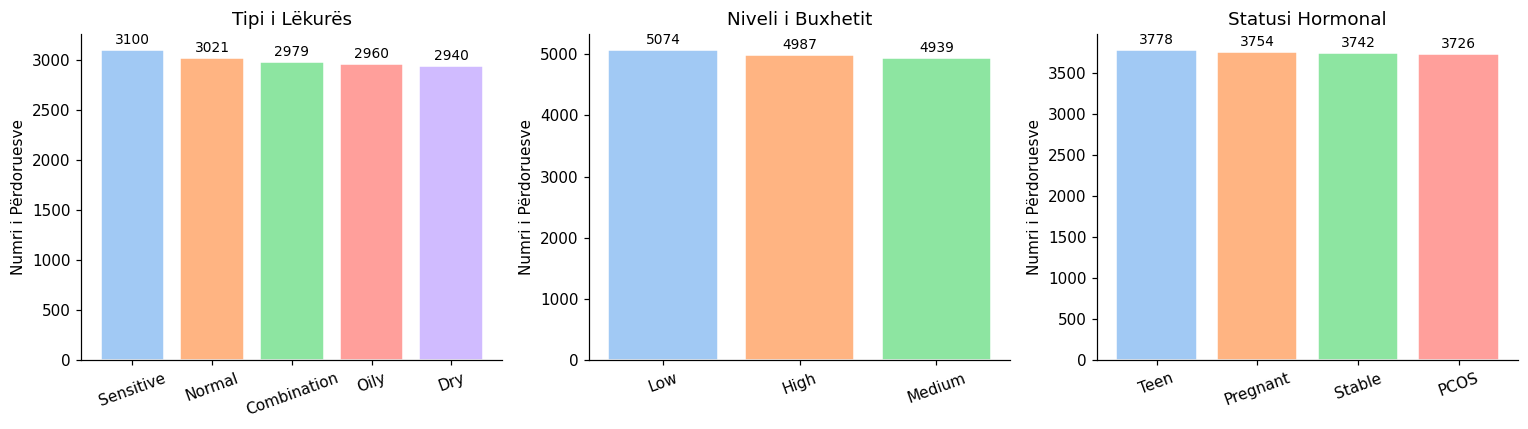

In [97]:
# Shpërndarja e tipit të lëkurës, buxhetit dhe statusit hormonal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
                           ['Skin_Type', 'Budget_Level', 'Hormonal_Status'],
                           ['Tipi i Lëkurës', 'Niveli i Buxhetit', 'Statusi Hormonal']):
    vc = users[col].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=sns.color_palette("pastel"), edgecolor='white')
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Numri i Përdoruesve")
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

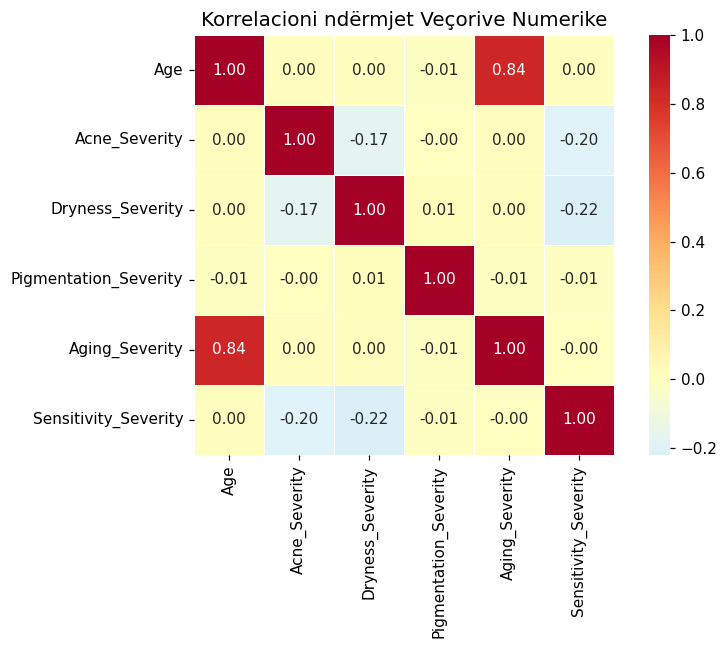

In [98]:
# Heatmap e korrelacionit ndërmjet veçorive numerike
numerical_cols = ['Age', 'Acne_Severity', 'Dryness_Severity',
                  'Pigmentation_Severity', 'Aging_Severity', 'Sensitivity_Severity']

corr_matrix = users[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Korrelacioni ndërmjet Veçorive Numerike", fontsize=13)
plt.tight_layout()
plt.show()

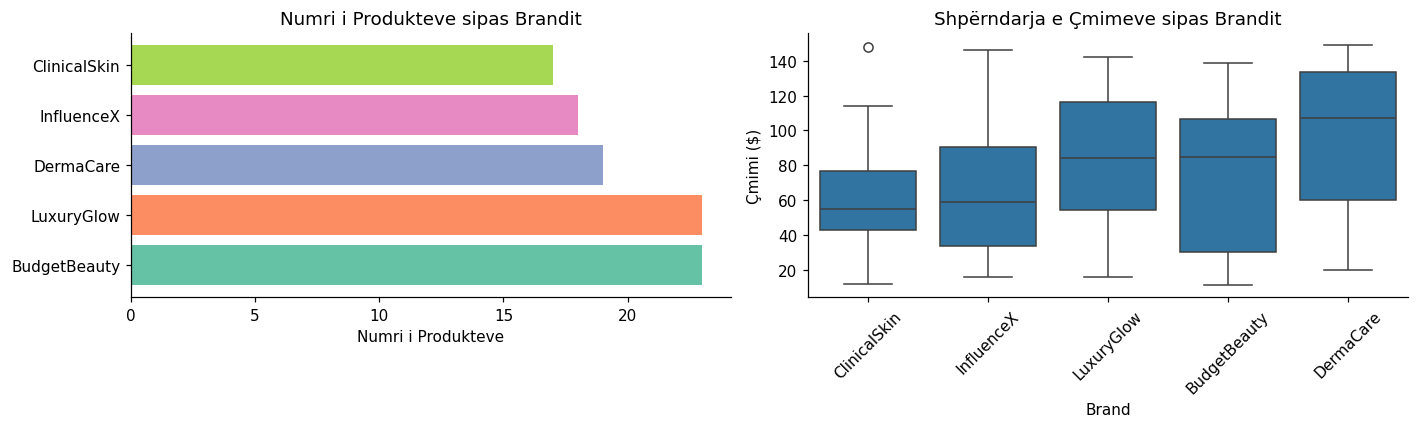

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Numri i produkteve sipas brandit
brand_counts = products['Brand'].value_counts()

axes[0].barh(
    brand_counts.index,
    brand_counts.values,
    color=sns.color_palette("Set2", len(brand_counts))
)
axes[0].set_title("Numri i Produkteve sipas Brandit")
axes[0].set_xlabel("Numri i Produkteve")

# Shpërndarja e çmimeve sipas brandit
brands_order = products.groupby('Brand')['Price'].median().sort_values().index

sns.boxplot(
    data=products,
    x='Brand',
    y='Price',
    order=brands_order,
    ax=axes[1]
)

axes[1].set_title("Shpërndarja e Çmimeve sipas Brandit")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Çmimi ($)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

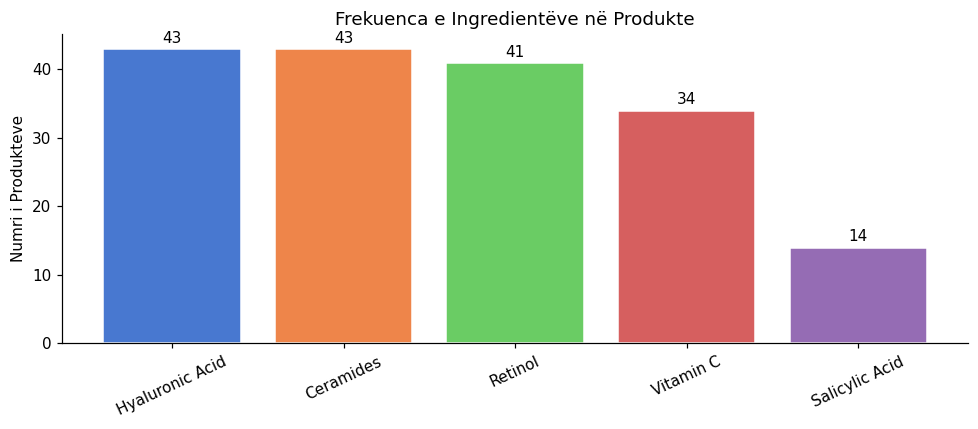

In [100]:
# Frekuenca e ingredientëve — cilët ingredientë gjenden më shpesh?
all_ingredients = [ing for sublist in products['Ingredients'] for ing in sublist]
ing_freq = Counter(all_ingredients).most_common()
labels, values = zip(*ing_freq)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, values, color=sns.color_palette("muted"), edgecolor='white')
ax.bar_label(bars, padding=2)
ax.set_title("Frekuenca e Ingredientëve në Produkte")
ax.set_ylabel("Numri i Produkteve")
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

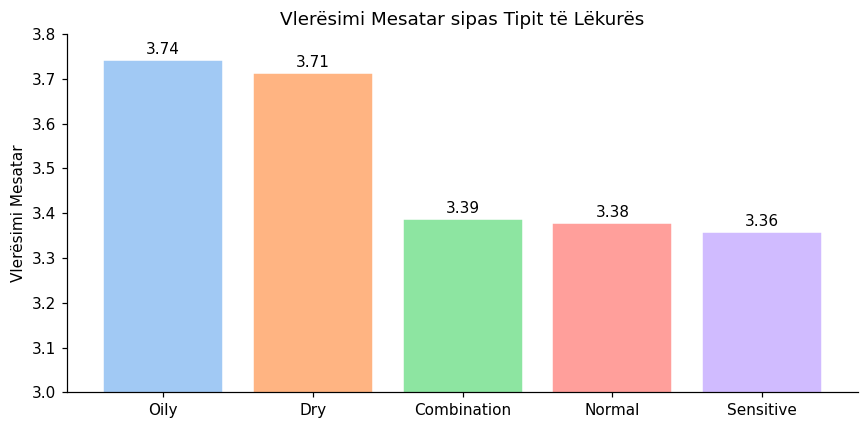

In [101]:
# Vlerësimi mesatar sipas tipit të lëkurës
merged_eda = interactions.merge(users[['User_ID', 'Skin_Type']], on='User_ID')
skin_rating = merged_eda.groupby('Skin_Type')['User_Rating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(skin_rating.index, skin_rating.values,
              color=sns.color_palette("pastel"), edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=2)
ax.set_ylim(3.0, 3.8)
ax.set_title("Vlerësimi Mesatar sipas Tipit të Lëkurës")
ax.set_ylabel("Vlerësimi Mesatar")
plt.tight_layout()
plt.show()

## 4. Inxhinieria e Veçorive (Feature Engineering)

In [102]:
# Bashkojmë tabelat
df = interactions.merge(users, on='User_ID')

df = df.merge(
    products[['Product_ID', 'Brand', 'Price']],
    on='Product_ID'
)

df = df.merge(ing_df, on='Product_ID')

print(f"Dataset i bashkuar: {df.shape[0]:,} rreshta × {df.shape[1]} kolona")

display(df.head(3))

Dataset i bashkuar: 12,464 rreshta × 22 kolona


,User_ID,Product_ID,User_Rating,Age,Skin_Type,Skin_Tone,Climate,Diet,Hormonal_Status,Budget_Level,...,Pigmentation_Severity,Aging_Severity,Sensitivity_Severity,Brand,Price,Ing_Ceramides,Ing_Hyaluronic Acid,Ing_Retinol,Ing_Salicylic Acid,Ing_Vitamin C
0,1,168,3.80,29,Sensitive,Deep,Cold,Vegan,Teen,High,...,4.333578,0.0,7.976537,DermaCare,64,0,1,0,1,0
1,2,119,3.37,22,Dry,Medium,Humid,High_Dairy,Pregnant,High,...,0.000000,0.0,0.000000,LuxuryGlow,57,1,0,1,0,1
2,4,467,4.06,33,Sensitive,Deep,Temperate,High_Dairy,PCOS,Medium,...,3.929117,0.0,5.225884,BudgetBeauty,99,1,1,1,0,0


In [103]:
# Veçori bazuar në historinë e vlerësimeve të çdo përdoruesi
user_stats = interactions.groupby('User_ID')['User_Rating'].agg(
    user_mean_rating='mean',
    user_rating_std='std',
    user_interactions='count'
).reset_index()

# Nëse përdoruesi ka vetëm 1 vlerësim, devijimi standard është NaN → e zëvendësojmë me 0
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)

df = df.merge(user_stats, on='User_ID')
print("Veçoritë e reja nga historia e përdoruesit: user_mean_rating, user_rating_std, user_interactions")

Veçoritë e reja nga historia e përdoruesit: user_mean_rating, user_rating_std, user_interactions


In [104]:
# Veçori bazuar në popullaritetin dhe vlerësimin mesatar të çdo produkti
product_stats = interactions.groupby('Product_ID')['User_Rating'].agg(
    product_mean_rating='mean',
    product_popularity='count'
).reset_index()

df = df.merge(product_stats, on='Product_ID')
print("Veçoritë e reja nga produkti: product_mean_rating, product_popularity")

Veçoritë e reja nga produkti: product_mean_rating, product_popularity


In [105]:
# Krijojmë target variable (etiketa):
# Vlerësim ≥ 4.0 → produkt i mirë (1), ndryshe → i keq (0)
df['label'] = (df['User_Rating'] >= 4.0).astype(int)

print("Shpërndarja e target-it:")
print(df['label'].value_counts().to_string())
print(f"\nRaporti i klasave: {df['label'].mean():.2%} pozitive (≥4.0)")

Shpërndarja e target-it:
label
0    9593
1    2871

Raporti i klasave: 23.03% pozitive (≥4.0)


In [106]:
# Kodojmë variablat kategorike me Label Encoding
# (konvertojmë tekst → numër, sepse modelet ML punojnë vetëm me numra)
cat_cols = ['Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level', 'Brand']
encoders = {}

df_ml = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le  # ruajmë encoder-in për t'u përdorur më vonë

print("Kolonat:", cat_cols)

Kolonat: ['Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level', 'Brand']


In [107]:
# Zgjedhim kolonat finale të veçorive (feature_cols)
ingredient_cols = [c for c in df_ml.columns if c.startswith('Ing_')]

feature_cols = (
    ['Age', 'Skin_Type', 'Skin_Tone', 'Climate', 'Diet', 'Hormonal_Status', 'Budget_Level',
     'Acne_Severity', 'Dryness_Severity', 'Pigmentation_Severity',
     'Aging_Severity', 'Sensitivity_Severity',
     'Brand', 'Price', 'product_mean_rating', 'product_popularity',
     'user_mean_rating', 'user_rating_std', 'user_interactions']
    + ingredient_cols
)

X = df_ml[feature_cols].values
y = df_ml['label'].values

print(f"Dimensionet e X (veçoritë): {X.shape}")
print(f"Numri total i veçorive: {len(feature_cols)}")

Dimensionet e X (veçoritë): (12464, 24)
Numri total i veçorive: 24


In [108]:
# Ndajmë të dhënat: 80% për trajnim, 20% për testim
# RËNDËSI: Ndajmë PARA normalizimit për të shmangur data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizojmë veçoritë (StandardScaler: mesatare=0, devijim=1)
# fit() vetëm mbi train — jo mbi test (ky është rregull i rëndësishëm!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape[0]:,} shembuj  |  Test: {X_test.shape[0]:,} shembuj")
print(f"Klasa pozitive në train: {y_train.mean():.2%}  |  Në test: {y_test.mean():.2%}")

Train: 9,971 shembuj  |  Test: 2,493 shembuj
Klasa pozitive në train: 23.04%  |  Në test: 23.02%


## 5. Klasifikimi

Implementojmë dhe vlerësojmë **5 klasifikues** me qasje të ndryshme:

| # | Modeli | Qasja |
|---|--------|-------|
| 1 | Decision Tree | Bazuar në pemë vendimmarrëse |
| 2 | Naive Bayes | Probabilistik (Bayes theorem) |
| 3 | Random Forest | Ansambël pemësh (voting) |
| 4 | KNN | Bazuar në distancë (K fqinjë) |
| 5 | SVM | Bazuar në kufi vendimmarrës |

Çdo model kalon nëpër **Hyperparameter Tuning** me GridSearchCV (5-fold cross-validation).

In [109]:
# Funksion ndihmës për vlerësimin e modeleve
# Ky funksion: trajnon modelin, parashikon, llogarit metrikat dhe printon rezultatin

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    # Trajnojmë modelin
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Llogarisim metrikat kryesore
    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_te, y_pred, zero_division=0),
    }

    # Printojmë raportin e detajuar
    print(f"{'─'*50}")
    print(f" {name}")
    print(f"{'─'*50}")
    print(classification_report(y_te, y_pred,
          target_names=['Vlerësim i Ulët', 'Vlerësim i Lartë']))

    return metrics, model, y_pred

# Lista ku do mbledhim rezultatet e të gjithë modeleve
all_results = []

5.1 Decision Tree

In [110]:
# Target: rutina sipas severity-t më të lartë
severity_to_routine = {
    'Acne_Severity': 'Acne Routine', 'Dryness_Severity': 'Hydration Routine',
    'Pigmentation_Severity': 'Brightening Routine', 'Aging_Severity': 'Anti-Aging Routine',
    'Sensitivity_Severity': 'Sensitive Skin Routine'
}
users_dt = users.copy()
users_dt['Routine'] = users_dt[list(severity_to_routine)].idxmax(axis=1).map(severity_to_routine)

print("Shpërndarja e klasave:")
print(users_dt['Routine'].value_counts().to_string())     

Shpërndarja e klasave:
Routine
Acne Routine              5919
Hydration Routine         3435
Sensitive Skin Routine    2898
Brightening Routine       2015
Anti-Aging Routine         733


In [111]:
# Encoding
feature_cols_dt = ['Age','Skin_Type','Skin_Tone','Climate','Diet','Hormonal_Status','Budget_Level',
                   'Acne_Severity','Dryness_Severity','Pigmentation_Severity','Aging_Severity','Sensitivity_Severity']
cat_cols_dt = ['Skin_Type','Skin_Tone','Climate','Diet','Hormonal_Status','Budget_Level']

enc_dt = {}
for col in cat_cols_dt:
    enc_dt[col] = LabelEncoder()
    users_dt[col] = enc_dt[col].fit_transform(users_dt[col])

le_target_dt = LabelEncoder()
X_dt = users_dt[feature_cols_dt].values
y_dt = le_target_dt.fit_transform(users_dt['Routine'])
class_names_dt = le_target_dt.classes_

print(f"Klasat: {list(class_names_dt)}")

Klasat: ['Acne Routine', 'Anti-Aging Routine', 'Brightening Routine', 'Hydration Routine', 'Sensitive Skin Routine']


In [112]:
#Train & Test
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt)
print(f"Train: {len(X_train_dt):,}  |  Test: {len(X_test_dt):,}")

Train: 12,000  |  Test: 3,000


In [113]:
#   Trajnimi 
dt = DecisionTreeClassifier(max_depth=7, min_samples_leaf=5, random_state=42)
dt.fit(X_train_dt, y_train_dt)

y_pred_dt = dt.predict(X_test_dt)

# Metricat 
print("   Decision Tree — Rezultatet ")
print(f"  Accuracy : {accuracy_score(y_test_dt, y_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_test_dt, y_pred_dt, average='weighted'):.4f}")
print(f"  Recall   : {recall_score(y_test_dt, y_pred_dt, average='weighted'):.4f}")
print(f"  F1-Score : {f1_score(y_test_dt, y_pred_dt, average='weighted'):.4f}")
print()
print(classification_report(y_test_dt, y_pred_dt, target_names=class_names_dt, digits=4))

   Decision Tree — Rezultatet 
  Accuracy : 0.9770
  Precision: 0.9769
  Recall   : 0.9770
  F1-Score : 0.9768

                        precision    recall  f1-score   support

          Acne Routine     0.9733    0.9848    0.9790      1184
    Anti-Aging Routine     0.9328    0.8503    0.8897       147
   Brightening Routine     0.9586    0.9777    0.9681       403
     Hydration Routine     0.9897    0.9767    0.9832       687
Sensitive Skin Routine     0.9931    0.9931    0.9931       579

              accuracy                         0.9770      3000
             macro avg     0.9695    0.9565    0.9626      3000
          weighted avg     0.9769    0.9770    0.9768      3000



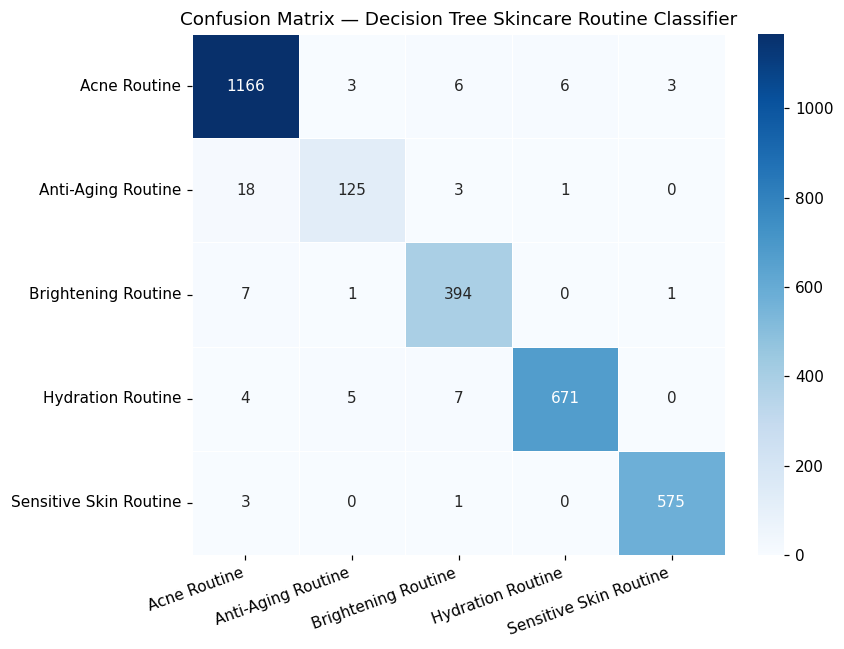

In [114]:
#Confusion Matrix
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_dt, yticklabels=class_names_dt,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Decision Tree Skincare Routine Classifier', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

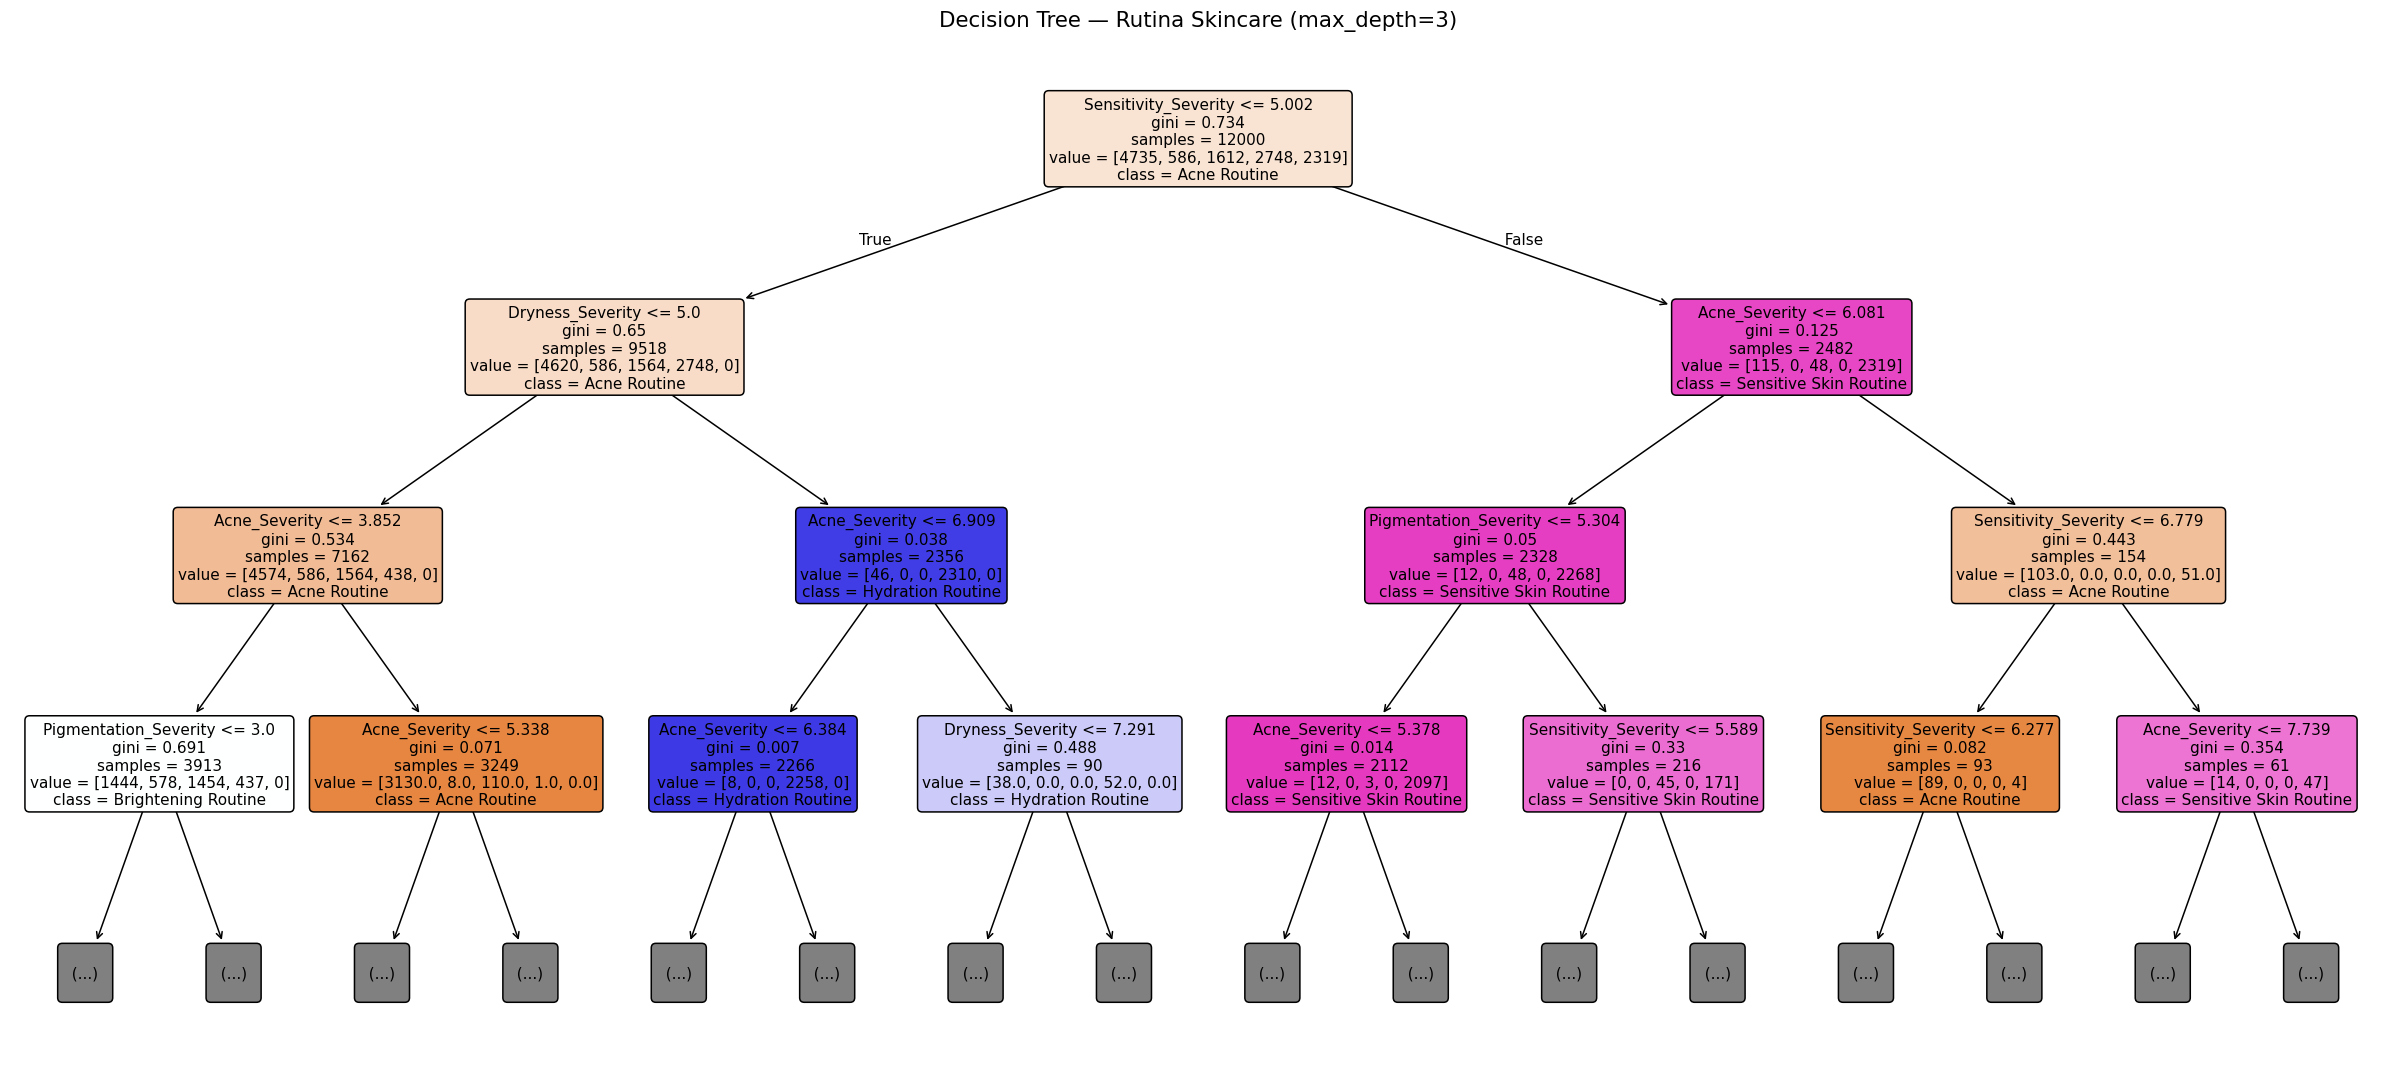

In [115]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_cols_dt,
    class_names=class_names_dt,
    filled=True,
    rounded=True,
    max_depth=3,         
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(
    'Decision Tree — Rutina Skincare (max_depth=3)',
    fontsize=14
)
plt.tight_layout()
plt.show()

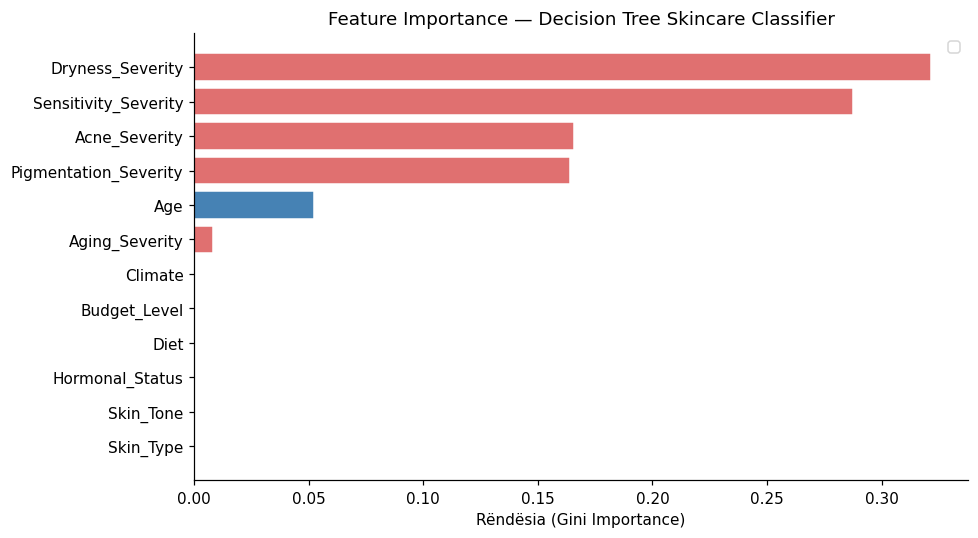

In [116]:
# Feature Importance
importances = pd.Series(dt.feature_importances_, index=feature_cols_dt)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#e07070' if 'Severity' in c else 'steelblue' for c in importances.index]
bars = ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importance — Decision Tree Skincare Classifier', fontsize=12)
ax.set_xlabel('Rëndësia (Gini Importance)')
ax.legend()
plt.tight_layout()
plt.show()

In [117]:
quiz = {'Age':22,'Skin_Type':'Oily','Skin_Tone':'Medium','Climate':'Humid','Diet':'Vegan',
        'Hormonal_Status':'Teen','Budget_Level':'Low','Acne_Severity':2,
        'Dryness_Severity':7,'Pigmentation_Severity':3,'Aging_Severity':1,'Sensitivity_Severity':4}

row = [enc_dt[col].transform([quiz[col]])[0] if col in enc_dt else quiz[col] for col in feature_cols_dt]
routine    = le_target_dt.inverse_transform(dt.predict([row]))[0]
confidence = dt.predict_proba([row])[0].max() * 100

print(f"Lëkura: {quiz['Skin_Type']} | Problemi dominant: Acne ({quiz['Acne_Severity']}/10)")
print(f" Rutina e rekomanduar: {routine} ({confidence:.1f}% besueshmëri)")

Lëkura: Oily | Problemi dominant: Acne (2/10)
 Rutina e rekomanduar: Hydration Routine (100.0% besueshmëri)


In [118]:
# Hyperparameter Tuning — Decision Tree
param_grid_dt = {'max_depth': [3, 5, 7, 10], 'min_samples_leaf': [1, 2, 5, 10], 'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_dt.fit(X_train_dt, y_train_dt)
print(f"Best params: {grid_dt.best_params_}")
print(f"Best F1: {grid_dt.best_score_:.4f}")

Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1}
Best F1: 0.9869


### 5.2 Naive Bayes (Gaussian)

In [119]:
# Trajnimi
nb = GaussianNB()
nb.fit(X_train_dt, y_train_dt)
y_pred_nb = nb.predict(X_test_dt)

print("Modeli u trajnua me sukses!")

Modeli u trajnua me sukses!


In [120]:
print(f"Accuracy : {accuracy_score(y_test_dt, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test_dt, y_pred_nb, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test_dt, y_pred_nb, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_test_dt, y_pred_nb, average='weighted'):.4f}")
print()
print(classification_report(y_test_dt, y_pred_nb, target_names=class_names_dt))

Accuracy : 0.7957
Precision: 0.8696
Recall   : 0.7957
F1-Score : 0.7986

                        precision    recall  f1-score   support

          Acne Routine       0.99      0.59      0.74      1184
    Anti-Aging Routine       0.39      0.97      0.56       147
   Brightening Routine       0.90      0.71      0.80       403
     Hydration Routine       0.68      0.98      0.80       687
Sensitive Skin Routine       0.94      1.00      0.97       579

              accuracy                           0.80      3000
             macro avg       0.78      0.85      0.77      3000
          weighted avg       0.87      0.80      0.80      3000



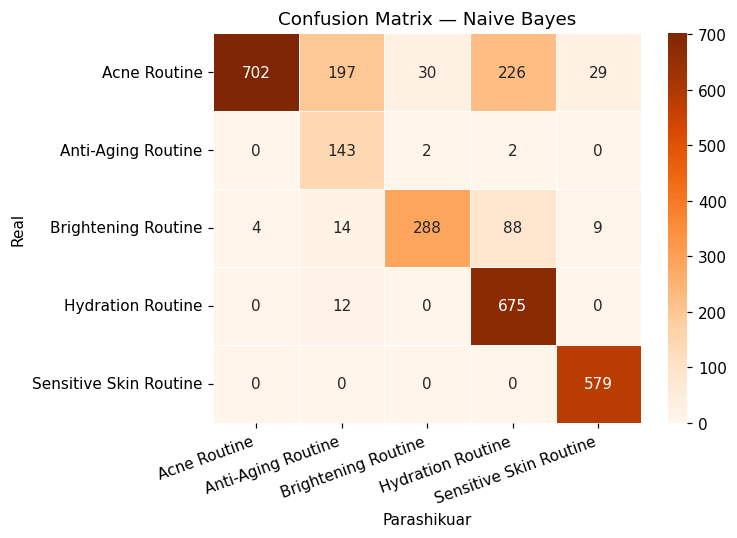

In [121]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test_dt, y_pred_nb), annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_dt, yticklabels=class_names_dt, linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Naive Bayes')
ax.set_xlabel('Parashikuar')
ax.set_ylabel('Real')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [122]:
# Hyperparameter Tuning — Naive Bayes
param_grid_nb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_nb.fit(X_train_dt, y_train_dt)
print(f"Best params: {grid_nb.best_params_}")
print(f"Best F1: {grid_nb.best_score_:.4f}")

Best params: {'var_smoothing': 1e-05}
Best F1: 0.9161


### 5.3 Random Forest

In [123]:
# Trajnimi
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_dt, y_train_dt)
y_pred_rf = rf.predict(X_test_dt)

print(f"Modeli u trajnua me sukses!")
print(f"Numri i pemëve: {rf.n_estimators}")

Modeli u trajnua me sukses!
Numri i pemëve: 100


In [124]:
print(f"Accuracy : {accuracy_score(y_test_dt, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test_dt, y_pred_rf, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test_dt, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_test_dt, y_pred_rf, average='weighted'):.4f}")
print()
print(classification_report(y_test_dt, y_pred_rf, target_names=class_names_dt))

Accuracy : 0.9880
Precision: 0.9880
Recall   : 0.9880
F1-Score : 0.9880

                        precision    recall  f1-score   support

          Acne Routine       0.99      0.99      0.99      1184
    Anti-Aging Routine       0.99      0.95      0.97       147
   Brightening Routine       0.97      0.98      0.97       403
     Hydration Routine       1.00      0.99      0.99       687
Sensitive Skin Routine       0.99      1.00      0.99       579

              accuracy                           0.99      3000
             macro avg       0.99      0.98      0.98      3000
          weighted avg       0.99      0.99      0.99      3000



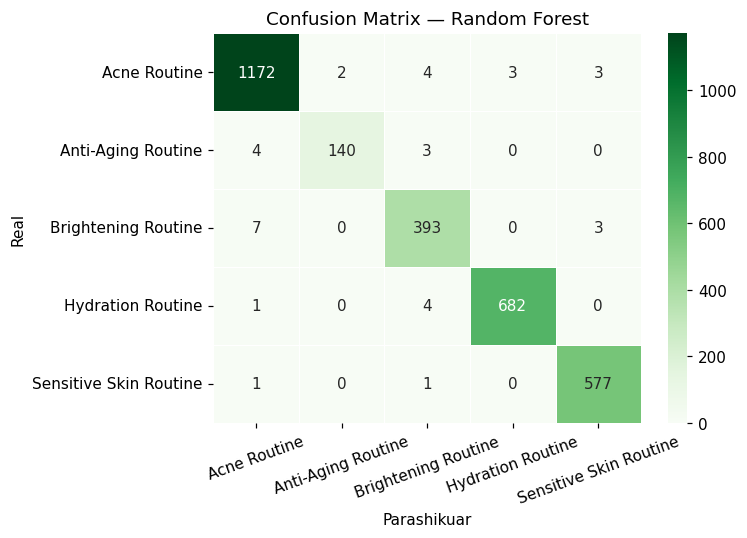

In [125]:
# Confusion Matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test_dt, y_pred_rf),annot=True,fmt='d',cmap='Greens',
    xticklabels=class_names_dt,yticklabels=class_names_dt,linewidths=0.5
)

plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Parashikuar')
plt.ylabel('Real')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

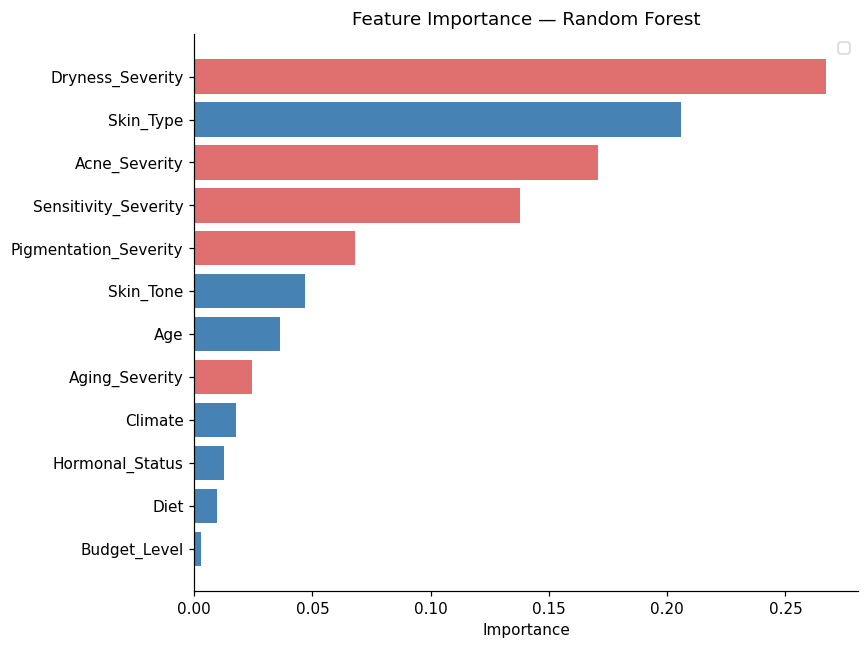

In [126]:
#Feature Importance
imp_rf = pd.Series(
    rf.feature_importances_,
    index=feature_cols_dt
)
imp_rf = imp_rf.sort_values()
plt.figure(figsize=(8, 6))

plt.barh(
    imp_rf.index,imp_rf.values,
    color=[
        '#e07070' if 'Severity' in c else 'steelblue'
        for c in imp_rf.index
    ]
)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')

plt.legend()

plt.tight_layout()
plt.show()

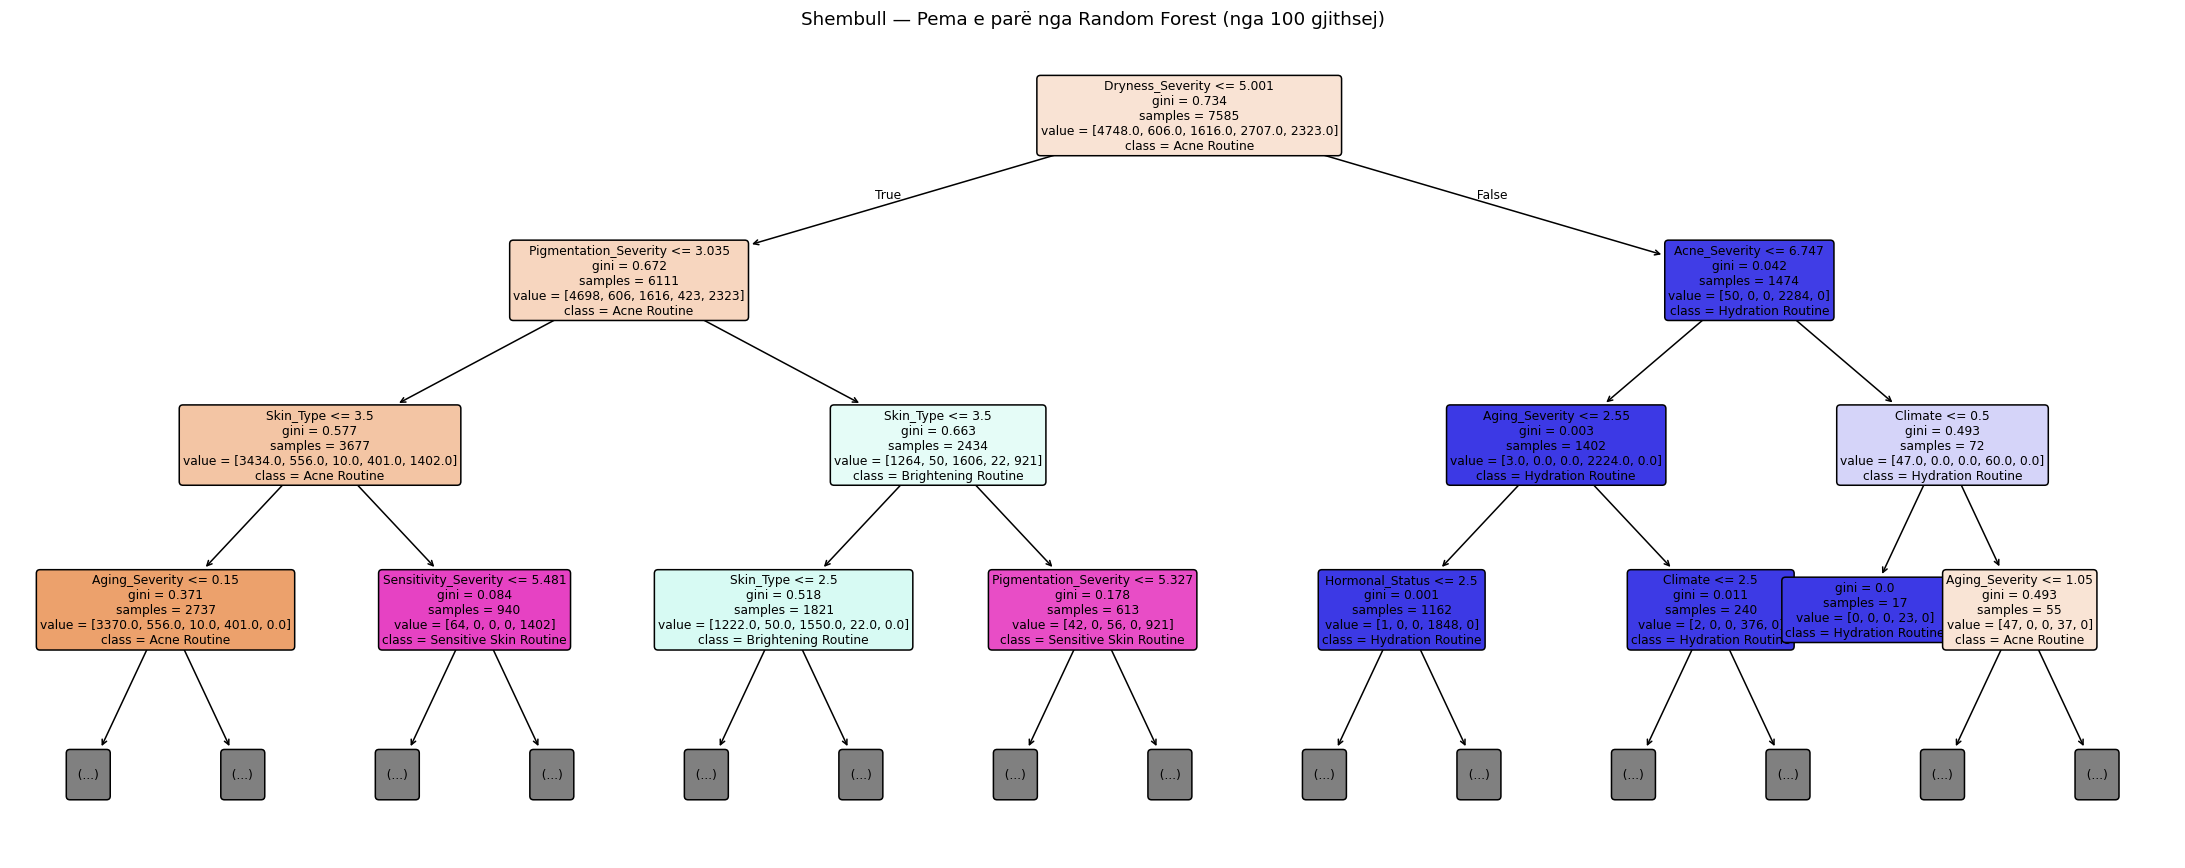

In [127]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(rf.estimators_[0],
          feature_names=feature_cols_dt,
          class_names=class_names_dt,
          filled=True, rounded=True,
          max_depth=3, fontsize=8, ax=ax)
ax.set_title('Shembull — Pema e parë nga Random Forest (nga 100 gjithsej)', fontsize=12)
plt.tight_layout()
plt.show()

In [128]:
routine_rf    = le_target_dt.inverse_transform(rf.predict([row]))[0]
confidence_rf = rf.predict_proba([row])[0].max() * 100

print(f"Lëkura: {quiz['Skin_Type']} | Problemi dominant: Acne ({quiz['Acne_Severity']}/10)")
print(f"✅ Rutina e rekomanduar (RF): {routine_rf} ({confidence_rf:.1f}% besueshmëri)")

Lëkura: Oily | Problemi dominant: Acne (2/10)
✅ Rutina e rekomanduar (RF): Hydration Routine (63.0% besueshmëri)


In [129]:
# Hyperparameter Tuning — Random Forest
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2, 5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_rf.fit(X_train_dt, y_train_dt)
print(f"Best params: {grid_rf.best_params_}")
print(f"Best F1: {grid_rf.best_score_:.4f}")

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best F1: 0.9857
